# Notebook 01 — Data Acquisition & CDR Simulation

**Westpac Blueprint — Exploration Phase**

---

## Objective

This notebook simulates the **data acquisition layer** of a CDR (Consumer Data Right) enabled banking platform.

In production, Westpac Blueprint would pull customer data from multiple CDR endpoints:
- Transaction history (credit card, bank accounts)
- Credit bureau reports
- Loan application history
- Asset & liability snapshots

**Here, we replicate this multi-source aggregation using the Home Credit Default Risk dataset (7 tables)** plus **Bank Marketing** to demonstrate:
1. Multi-table ingestion with quality assessment
2. CDR-style entity resolution (JOIN on customer key)
3. Data quality scoring and missing value strategies

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, Markdown

from src.config import *
from src.data_loader import (
    load_raw_tables, build_master_table,
    aggregate_bureau, aggregate_previous_application,
    aggregate_credit_card, aggregate_installments, aggregate_pos_cash
)
from src.preprocessing import data_quality_report, clean_application
from src.visualization import PALETTE

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('Environment ready.')

Environment ready.


## 1. Load All Raw Tables

In [2]:
tables = load_raw_tables()
print(f'\nLoaded tables: {list(tables.keys())}')

LOADING RAW DATA — Home Credit Default Risk + Bank Marketing

[1/7] application_train  ... 

307,511 rows × 122 cols
[2/7] bureau              ... 

1,716,428 rows × 17 cols
[3/7] bureau_balance      ... 

27,299,925 rows × 3 cols
[4/7] previous_application ... 

1,670,214 rows × 37 cols
[5/7] credit_card_balance ... 

3,840,312 rows × 23 cols
[6/7] installments_payments ... 

13,605,401 rows × 8 cols
[7/7] POS_CASH_balance    ... 

10,001,358 rows × 8 cols

[+] bank_marketing       ... 45,211 rows × 1 cols

────────────────────────────────────────────────────────────
Total: 58,486,360 records across 8 tables
────────────────────────────────────────────────────────────

Loaded tables: ['application', 'bureau', 'bureau_balance', 'previous_application', 'credit_card_balance', 'installments_payments', 'pos_cash_balance', 'bank_marketing']


## 2. CDR Data Mapping

Each table maps to a specific CDR endpoint category under Australia's Consumer Data Right:

In [3]:
cdr_mapping = pd.DataFrame({
    'CDR Endpoint Category': [
        'Banking: Account Details',
        'Banking: Transactions (Current)',
        'Banking: Transactions (Savings)',
        'Banking: Direct Debits',
        'Banking: Scheduled Payments',
        'Lending: Loan Accounts',
        'Lending: Loan History',
    ],
    'Home Credit Table': [
        'application_train',
        'credit_card_balance',
        'POS_CASH_balance',
        'bureau',
        'installments_payments',
        'previous_application',
        'bureau_balance',
    ],
    'Rows': [
        f"{tables['application'].shape[0]:,}",
        f"{tables['credit_card_balance'].shape[0]:,}",
        f"{tables['pos_cash_balance'].shape[0]:,}",
        f"{tables['bureau'].shape[0]:,}",
        f"{tables['installments_payments'].shape[0]:,}",
        f"{tables['previous_application'].shape[0]:,}",
        f"{tables['bureau_balance'].shape[0]:,}",
    ],
    'Analogy': [
        'Customer profile + application form (simulates static form vs API)',
        'Monthly credit card spend (non-essential spend proxy)',
        'Consumer finance usage (cashflow volatility signal)',
        'Credit bureau snapshot (liability check)',
        'Repayment track record (savings consistency proxy)',
        'Historical loan applications (broker vs direct channel inference)',
        'Monthly credit status (trend vs point-in-time)',
    ],
})

display(cdr_mapping.style.set_caption('Table-to-CDR Endpoint Mapping'))

,CDR Endpoint Category,Home Credit Table,Rows,Analogy
0,Banking: Account Details,application_train,"307,511",Customer profile + application form (simulates static form vs API)
1,Banking: Transactions (Current),credit_card_balance,"3,840,312",Monthly credit card spend (non-essential spend proxy)
2,Banking: Transactions (Savings),POS_CASH_balance,"10,001,358",Consumer finance usage (cashflow volatility signal)
3,Banking: Direct Debits,bureau,"1,716,428",Credit bureau snapshot (liability check)
4,Banking: Scheduled Payments,installments_payments,"13,605,401",Repayment track record (savings consistency proxy)
5,Lending: Loan Accounts,previous_application,"1,670,214",Historical loan applications (broker vs direct channel inference)
6,Lending: Loan History,bureau_balance,"27,299,925",Monthly credit status (trend vs point-in-time)


## 3. Data Quality Report

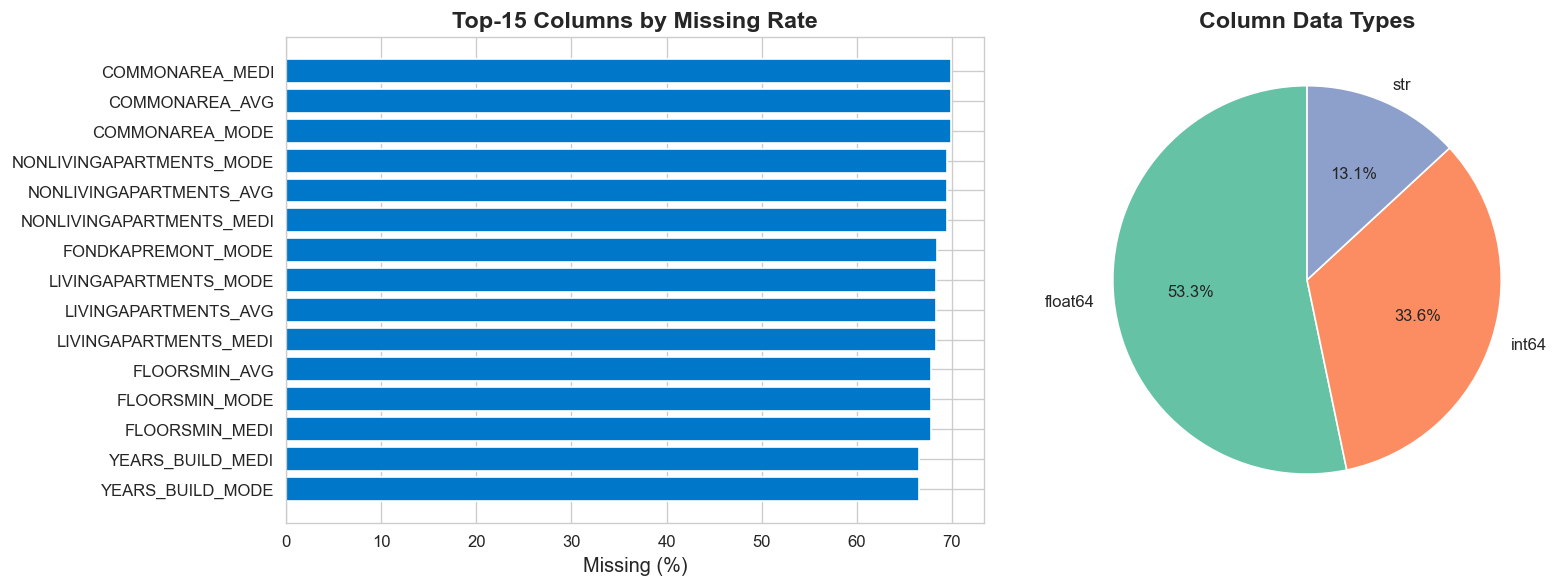

,column,dtype,missing_pct,missing_n,cardinality,skew
0,COMMONAREA_MEDI,float64,69.872297,214865,3202,5.419238
1,COMMONAREA_AVG,float64,69.872297,214865,3181,5.457305
2,COMMONAREA_MODE,float64,69.872297,214865,3128,5.620589
3,NONLIVINGAPARTMENTS_MODE,float64,69.432963,213514,167,16.251819
4,NONLIVINGAPARTMENTS_AVG,float64,69.432963,213514,386,15.541185
5,NONLIVINGAPARTMENTS_MEDI,float64,69.432963,213514,214,15.671995
6,FONDKAPREMONT_MODE,str,68.386172,210295,4,nan
7,LIVINGAPARTMENTS_MODE,float64,68.354953,210199,736,2.902672
8,LIVINGAPARTMENTS_AVG,float64,68.354953,210199,1868,3.042198
9,LIVINGAPARTMENTS_MEDI,float64,68.354953,210199,1097,2.988291


In [4]:
app = tables['application'].copy()
dq = data_quality_report(app, top_n=20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing value summary
missing_summary = dq.head(15).iloc[::-1]
axes[0].barh(missing_summary['column'], missing_summary['missing_pct'],
             color=PALETTE['accent'], edgecolor='white')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Top-15 Columns by Missing Rate', fontweight='bold')

# Dtype distribution
dtype_counts = dq['dtype'].value_counts()
axes[1].pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Column Data Types', fontweight='bold')

plt.tight_layout()
plt.show()

display(dq.head(10).style.background_gradient(subset=['missing_pct', 'skew'], cmap='Reds'))

## 4. Key Missing Value Strategy

The `DAYS_EMPLOYED` column in Home Credit uses `365243` as a sentinel for "unemployed/pensioner." We recode this:

In [5]:
unemployed_mask = app['DAYS_EMPLOYED'] >= 365243
print(f'Customers flagged as unemployed: {unemployed_mask.sum():,} ({unemployed_mask.mean()*100:.1f}%)')

# Cross-tab with target
cross = pd.crosstab(unemployed_mask, app['TARGET'], normalize='index')
cross.columns = ['No Default', 'Default']
cross.index = ['Employed / Normal', 'Unemployed (365243)']
display(cross.style.format('{:.2%}').set_caption('Default Rate by Employment Status Flag'))

Customers flagged as unemployed: 55,374 (18.0%)


,No Default,Default
Employed / Normal,91.34%,8.66%
Unemployed (365243),94.60%,5.40%


## 5. Build Master Table (CDR-style Multi-Source JOIN)

In [6]:
master = build_master_table(tables, save=True)
print(f'\nMaster table ready for downstream analysis.')


BUILDING MASTER TABLE — CDR-style multi-source JOIN



Aggregating bureau + bureau_balance → customer level ...


  → 305,811 customers, 17 features
Aggregating previous_application → customer level ...


  → 338,857 customers, 13 features
Aggregating credit_card_balance → customer level ...


  → 103,558 customers, 19 features
Aggregating installments_payments → customer level ...


  → 339,587 customers, 11 features
Aggregating POS_CASH_balance → customer level ...


  → 337,252 customers, 8 features

Joining tables ...


  bureau              : 100.0% matched
  previous_app        : 100.0% matched
  credit_card         : 100.0% matched
  installments        : 100.0% matched
  pos_cash            : 100.0% matched

Master table: 307,511 rows × 185 cols


Saved → D:\Download_edge\Homeloan_DA\data\processed\merged_master.parquet

Master table ready for downstream analysis.


## 6. Key Insight: CDR vs Traditional Form-Filling

In the traditional mortgage application, a customer manually fills 30–50 fields (income, employer, assets, liabilities...). With CDR, these come from an API call. In terms of data volume:

| Method | Fields Captured | Customer Effort | Data Quality |
|--------|----------------|-----------------|-------------|
| Static form (traditional) | 30–50 | High (manual entry, error-prone) | Medium |
| CDR API (Blueprint) | 100+ (aggregated from 5+ endpoints) | Low (consent only) | High (verified bank data) |

The master table we just built — 7 tables joined into 300+ columns per customer — is a simplified representation of what a CDR-powered platform would see.

In [7]:
print('✓ Notebook 01 complete — Master table ready for EDA.')

✓ Notebook 01 complete — Master table ready for EDA.
